<a href="https://colab.research.google.com/github/MouseLand/cellpose/blob/main/notebooks/run_Cellpose-SAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Run Cellpose-SAM

Adapted from Marius Pachitariu, Michael Rariden, Carsen Stringer and the notebook by Pradeep Rajasekhar, inspired by the [ZeroCostDL4Mic notebook series](https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki)

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

### Make sure you are in the correct environment


In [32]:
# Check GPU and instantiate model - will download weights.
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
import cv2 as cv 
import tifffile as tf
%matplotlib inline
from natsort import natsorted

io.logger_setup() # run this to get printing of progress

#Check if GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

2025-05-13 15:51:46,067 [INFO] WRITING LOG OUTPUT TO /home/mattiazzilab/.cellpose/run.log
2025-05-13 15:51:46,068 [INFO] 
cellpose version: 	4.0.2 
platform:       	linux 
python version: 	3.8.18 
torch version:  	2.4.1
2025-05-13 15:51:46,068 [INFO] ** TORCH CUDA version installed and working. **
2025-05-13 15:51:46,068 [INFO] ** TORCH CUDA version installed and working. **
2025-05-13 15:51:46,069 [INFO] >>>> using GPU (CUDA)
2025-05-13 15:51:46,912 [INFO] >>>> loading model /home/mattiazzilab/.cellpose/models/cpsam


Input directory with your images:
- Note - For best accuracy and runtime performance, resize images so cells are less than 100 pixels across

In [33]:
# *** change to your google drive folder path ***
dir = "/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/test_images"
dir = Path(dir)
if not dir.exists():
  raise FileNotFoundError("directory does not exist")

# *** change to your image extension ***
image_ext = ".tif"

# list all files
files = natsorted([f for f in dir.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name])

if(len(files)==0):
  raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
else:
  print(f"{len(files)} images in folder:")

for f in files:
  print(f.name)

5 images in folder:
MAX_ch1-r02c09f01.tif
MAX_ch2-r02c09f01.tif
MAX_ch3-r02c09f01.tif
MAX_ch4-r02c09f01.tif
r03c03f04.tif


## Run Cellpose-SAM on one image in folder

Here are some of the parameters you can change:

* ***flow_threshold*** is  the  maximum  allowed  error  of  the  flows  for  each  mask.   The  default  is 0.4.
    *  **Increase** this threshold if cellpose is not returning as many masks as you’d expect (or turn off completely with 0.0)
    *   **Decrease** this threshold if cellpose is returning too many ill-shaped masks.

* ***cellprob_threshold*** determines proability that a detected object is a cell.   The  default  is 0.0.
    *   **Decrease** this threshold if cellpose is not returning as many masks as you’d expect or if masks are too small
    *   **Increase** this threshold if cellpose is returning too many masks esp from dull/dim areas.

* ***tile_norm_blocksize*** determines the size of blocks used for normalizing the image. The default is 0, which means the entire image is normalized together.
  You may want to change this to 100-200 pixels if you have very inhomogeneous brightness across your image.



(<Figure size 988.8x604.8 with 1 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x7f2172259520>)

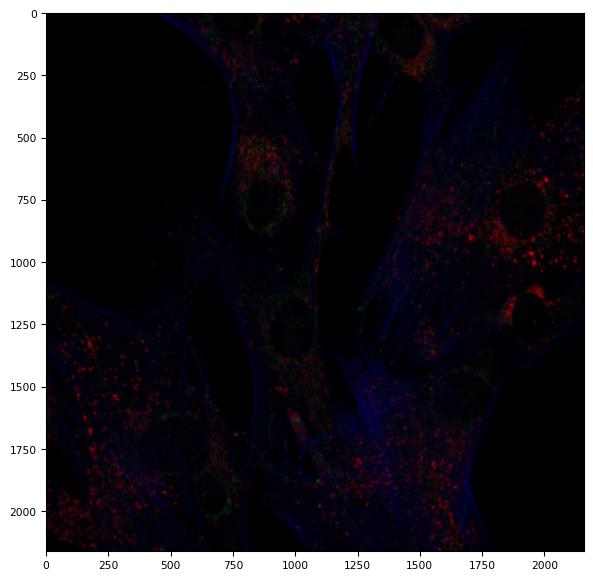

In [ ]:
ch1,ch2,ch3 = io.imread(files[0]), io.imread(files[1]), io.imread(files[3])
multi_channel_image = np.stack((ch1, ch2, ch3), axis=-1)

tf.imshow(multi_channel_image)


2025-05-13 15:45:14,350 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
2025-05-13 15:45:17,970 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


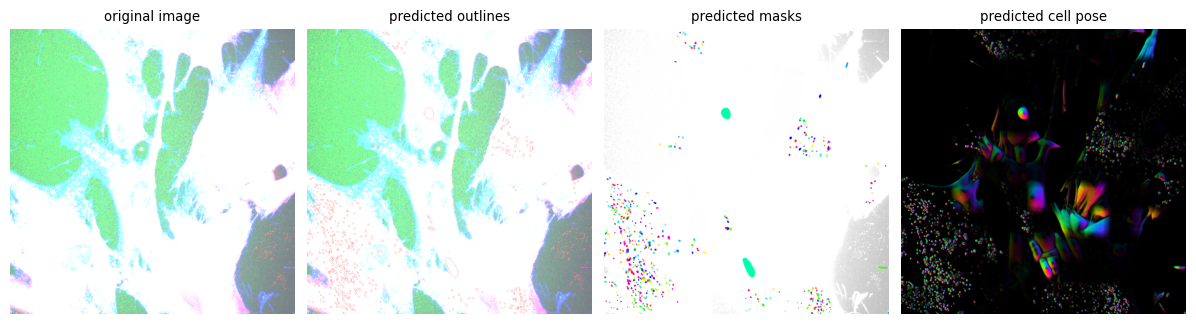

In [29]:
img = multi_channel_image
#img = io.imread(files[0])

flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

masks, flows, styles = model.eval(img, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img, masks, flows[0])
plt.tight_layout()
plt.show()


## Run Cellpose-SAM on folder of images

if you have many large images, you may want to run them as a loop over images



In [ ]:
masks_ext = ".png" if image_ext == ".png" else ".tif"
for i in trange(len(files)):
    f = files[i]
    img = io.imread(f)
    masks, flows, styles = model.eval(img, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks)

if you have small images, you may want to load all of them first and then run, so that they can be batched together on the GPU

In [ ]:
print("loading images")
imgs = [io.imread(files[i]) for i in trange(len(files))]

print("running cellpose-SAM")
masks, flows, styles = model.eval(imgs, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

print("saving masks")
for i in trange(len(files)):
    f = files[i]
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks[i])

to save your masks for ImageJ, run the following code:

In [ ]:
for i in trange(len(files)):
    f = files[i]
    masks0 = io.imsave(dir / (f.name + "_masks" + masks_ext))
    io.save_rois(masks0, f)